In [15]:
%reload_ext autoreload
%autoreload 2

In [16]:
import src
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [17]:
Dataset, CycleOfLife = src.get_data()
labeled_df = src.get_quantile(CycleOfLife)
features = src.extract_battery_features(Dataset)

In [50]:
filtered = src.filtered_features(features, labeled_df)

X_train, X_test, y_train, y_test = src.separeData(filtered)

X_train

,time_above_3_9V_total,time_above_3_5V_cycle1,max_Q_charge_cycle1,max_E_charge_cycle1,time_between_3_9V_4_0V,mean_voltage_charge,var_voltage_charge,mean_current_charge,max_voltage_absolute,min_voltage_absolute,peak_height_dQ_dV,peak_location_dQ_dV,peak_height_dE_dV,peak_location_dE_dV,peak_height_dV_dQ,peak_location_dV_dQ,consumed_lithium_loss,voltage_drop_relaxation_1s,voltage_drop_relaxation_10s,voltage_drop_relaxation_60s
0,41984.24,27974.23,2.376408,8.985356,11431.95,3.223508,0.782709,0.279084,4.200122,0.004273,3187.566172,4.199741,13235.253756,4.199741,9.904348e+03,0.183108,0.009364,-0.018463,-0.092851,-1.628290
16,41329.67,27694.21,2.382600,9.001430,11327.23,3.219123,0.787941,0.279070,4.200122,0.002365,2989.119769,4.199817,12229.028250,4.199817,9.711140e+03,0.167315,0.013674,-0.018540,-0.099336,-1.644312
24,42825.72,3171.12,0.498248,2.031778,6997.92,3.892571,0.189441,0.778949,4.200122,0.002365,22605.791332,4.199817,84285.879497,4.199817,3.814727e+05,3.919280,0.005006,-0.005035,-0.010224,-0.753033
38,42984.77,3123.03,0.489114,1.993923,6465.82,3.891150,0.187805,0.785795,4.200198,0.001526,28037.437034,4.200046,107274.004648,4.200046,4.015526e+04,3.918822,0.003352,-0.000229,0.108263,0.010910
15,42240.52,27368.23,2.355934,8.904320,11735.79,3.228407,0.780057,0.279064,4.199969,0.003891,122.984245,3.784848,501.696961,3.784848,1.036902e+04,0.214160,0.002150,-0.012284,-0.086824,-1.606699
18,42296.69,27978.46,2.356377,8.908285,11672.57,3.223972,0.785740,0.279049,4.199969,0.004273,3005.571860,4.199741,12397.970413,4.199741,1.019565e+04,0.206378,-0.003748,-0.018311,-0.092164,-1.622339
33,41306.77,3136.32,0.491879,2.005921,6161.97,3.893163,0.187278,0.789880,4.200122,0.001373,27309.353887,4.067445,104337.680655,4.067445,5.747496e+03,1.084993,0.004050,-0.380102,-0.181048,-0.369802
11,43642.01,28273.84,2.380469,8.998912,11640.12,3.224624,0.779561,0.279057,4.200046,0.005951,4679.918746,4.200046,19479.382117,4.200046,9.918375e+06,3.390402,-0.003793,-0.018311,-0.092851,-1.626612
6,42595.55,28056.09,2.367998,8.950811,11694.75,3.222336,0.789732,0.279052,4.199969,0.000992,4879.063564,4.199893,20514.205771,4.199893,9.781284e+03,0.187076,-0.004304,-0.012360,-0.843671,-1.625772
39,42611.52,3093.50,0.485446,1.980107,6051.08,3.895081,0.188673,0.777515,4.200122,0.000687,29361.624981,4.199817,112970.245556,4.199817,3.390889e+05,3.921340,0.004279,-0.005112,-0.709468,-0.747692


In [51]:
filtered_PCA = filtered.drop(columns=['cell_id', 'label'])

In [52]:
scaler = sklearn.preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [53]:
pca = sklearn.decomposition.PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

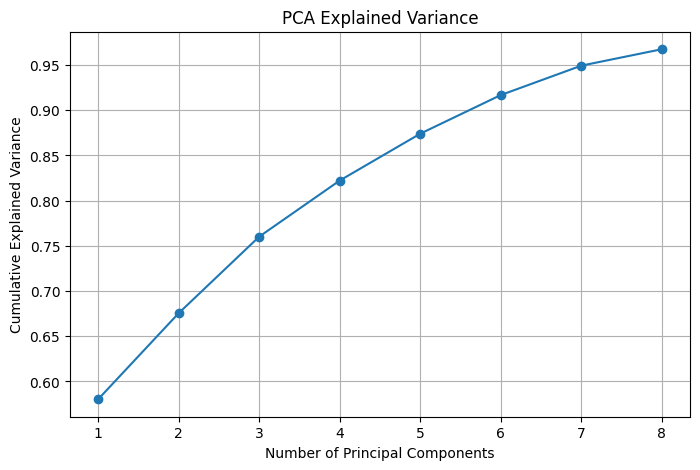

In [54]:
import numpy as np

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(explained_variance) + 1),
    np.cumsum(explained_variance),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [57]:
pca_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]

features_pca = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=X_train.index
)

features_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,2.773078,0.744158,-1.077439,0.330259,1.889239,0.187453,0.165249,0.389826
16,2.747308,0.694437,-1.792059,0.365423,2.570819,-0.171687,0.552477,0.363400
24,-3.007833,0.025521,0.238150,-0.081787,0.431751,-0.661887,-0.620794,-0.366850
38,-3.992915,-0.124258,0.679496,-0.248214,0.646574,-0.174501,-0.788360,-0.577795
15,3.957379,-2.393918,0.246450,-1.514522,0.390384,-0.113292,1.172706,0.880807


In [56]:
print(features.shape)
print(X_train.shape)
print(X_pca.shape)

(40, 21)
(28, 20)
(28, 8)
